📅 День 10 — Мини-проект

Проект:

загрузить датасет (cats vs dogs)

подготовить DataLoader

визуализация

✅ Итог: готовые данные для CNN

Вариант 1. Датасет Pets
========

Загрузка датасета
=======

In [2]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

100.0%


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100.0%


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet


DataLoader
=====

In [3]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

In [4]:
images, labels = next(iter(loader))
print(images.shape)

torch.Size([16, 3, 224, 224])


Визуализация батча
====

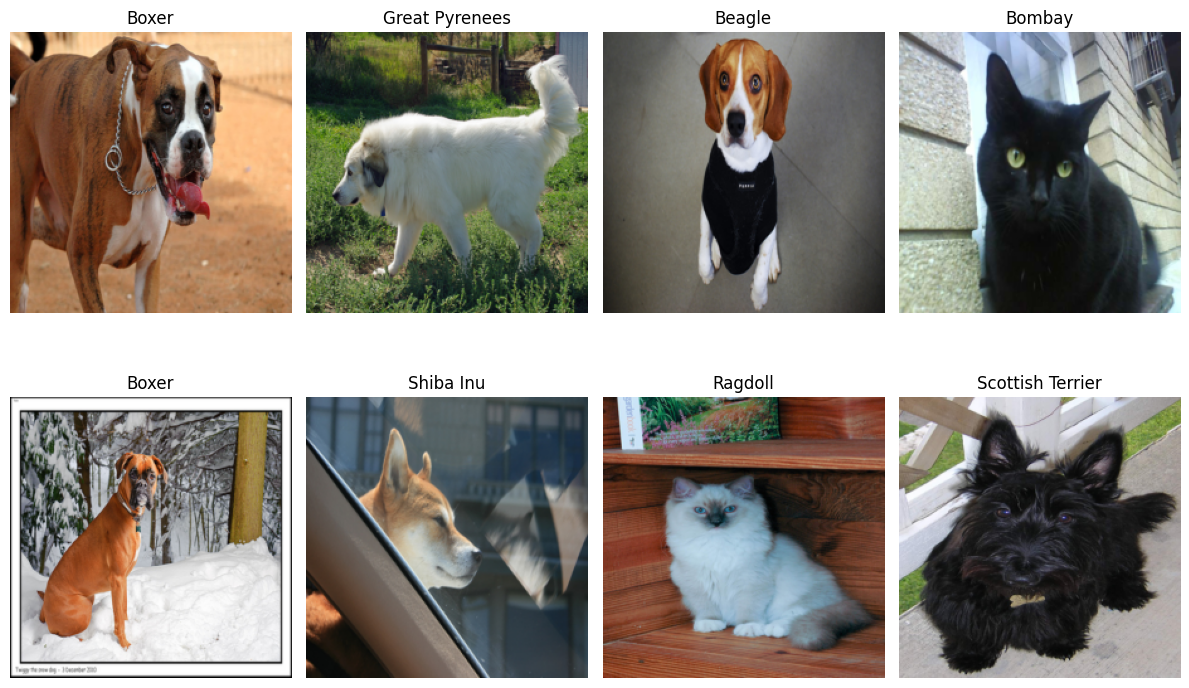

In [6]:
import matplotlib.pyplot as plt

class_names = dataset.classes

def show_batch(images, labels):
    plt.figure(figsize=(12,8))
    
    for i in range(8):
        plt.subplot(2,4,i+1)
        
        img = images[i].permute(1,2,0)
        plt.imshow(img)
        
        plt.title(class_names[labels[i]])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

Вариант 2. Датасет Cats vs Dogs
=======

Загрузка датасета
=====

In [4]:
#!pip install kaggle

In [3]:
!kaggle datasets download karakaggle/kaggle-cat-vs-dog-dataset

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown




  0%|          | 0.00/787M [00:00<?, ?B/s]
 14%|#4        | 114M/787M [00:00<00:00, 1.19GB/s]
 31%|###1      | 246M/787M [00:00<00:00, 1.28GB/s]
 47%|####6     | 369M/787M [00:00<00:00, 783MB/s] 
 63%|######2   | 494M/787M [00:00<00:00, 932MB/s]
 79%|#######9  | 625M/787M [00:00<00:00, 1.06GB/s]
 94%|#########3| 739M/787M [00:00<00:00, 801MB/s] 
100%|##########| 787M/787M [00:00<00:00, 906MB/s]


Нужно разахивировать kaggle-cat-vs-dog-dataset.zip в папаку \data

DataLoader
=====
Изображения уже разбиты на папки Cat и Dog. И названия папок станут классами для изображений в них.

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(r"data\kagglecatsanddogs_3367a\PetImages", transform=transform)

loader = DataLoader(dataset, batch_size=16, shuffle=True)

images, labels = next(iter(loader))
print(images.shape)

torch.Size([16, 3, 224, 224])


In [11]:
print(labels)

tensor([1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0])


Визуализация батча
======

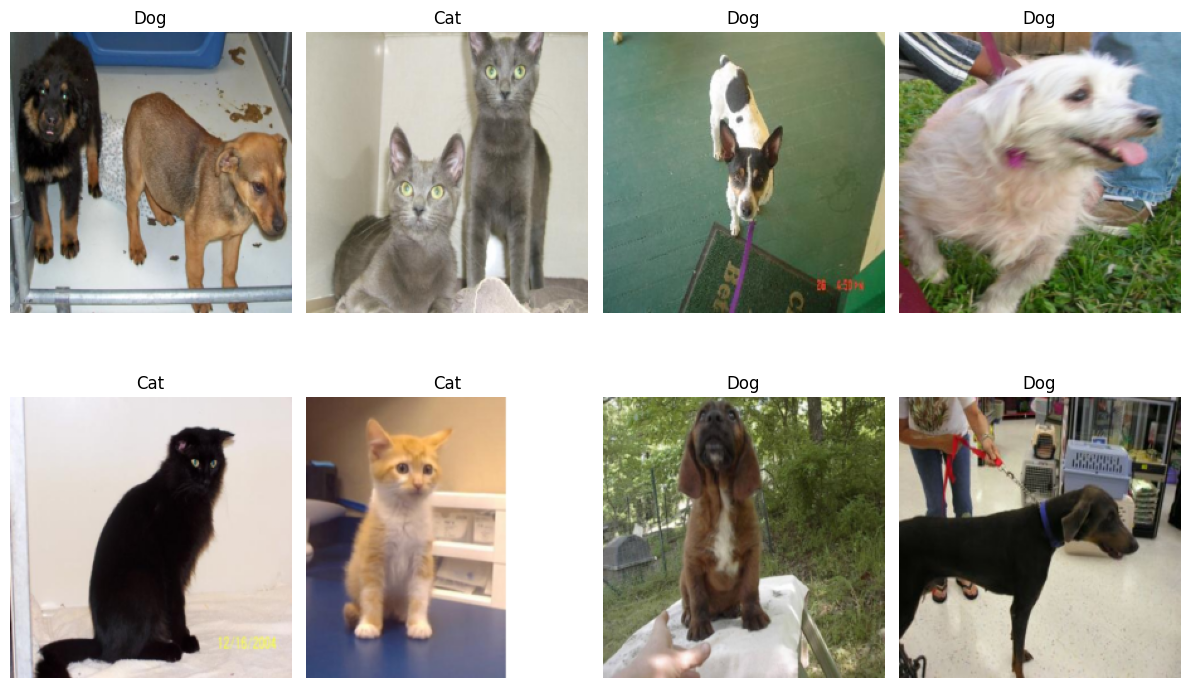

In [9]:
import matplotlib.pyplot as plt

class_names = dataset.classes

def show_batch(images, labels):
    plt.figure(figsize=(12,8))
    
    for i in range(8):
        plt.subplot(2,4,i+1)
        
        img = images[i].permute(1,2,0)
        plt.imshow(img)
        
        plt.title(class_names[labels[i]])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

In [12]:
print(class_names)

['Cat', 'Dog']
